##Collect Data from Reddit

In [ ]:
pip install praw

In [ ]:
import praw
import datetime

In [ ]:
CLIENT_ID = 'VZ5PJkrWp1d8iMg7rU4EYA'
CLIENT_SECRET = 'cjdg1-jkC93DJ3tfCLhLwpqfqF-Dkw'
USER_AGENT = 'RihannaSubredditScraper'

In [ ]:
reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

In [ ]:
subreddit_name = 'Rihanna'
subreddit = reddit.subreddit(subreddit_name)

In [ ]:
comments_data = []

In [ ]:
comment_count = 0

In [ ]:
target_comments = 1000

In [ ]:
for submission in subreddit.hot(limit=200):
    if comment_count >= target_comments:
        break

    submission.comments.replace_more(limit=None)
    for comment in submission.comments.list():
        if comment_count >= target_comments:
            break

        if hasattr(comment, 'body') and comment.body and comment.author:
            comments_data.append({
                'comment_id': comment.id,
                'submission_id': comment.submission.id,
                'submission_title': comment.submission.title,
                'author': comment.author.name if comment.author else '[deleted]',
                'comment_body': comment.body,
                'score': comment.score,
                'created_utc': datetime.datetime.fromtimestamp(comment.created_utc).strftime('%Y-%m-%d %H:%M:%S')
            })
            comment_count += 1
            if comment_count % 50 == 0:
                print(f"Collected {comment_count} comments so far...")

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(comments_data)

In [ ]:
df

In [ ]:
output_filename = f'{subreddit_name}_reddit_comments_{datetime.date.today()}.csv'

In [ ]:
df.to_csv(output_filename, index=False)

In [ ]:
rihanna_df = pd.read_csv('/content/Rihanna_reddit_comments_2025-07-06.csv')

In [ ]:
rihanna_df

,comment_id,submission_id,submission_title,author,comment_body,score,created_utc
0,mzpts9b,1lk882p,Savage X Fenty - June 2025,VapidRapidRabbit,Just casually scrolling and GODDAMN.,23,25/06/2025 15:54
1,mzpy27r,1lk882p,Savage X Fenty - June 2025,RekserPL,I love Rihanna's body she is so hot 🔥,14,25/06/2025 16:14
2,mzq2wii,1lk882p,Savage X Fenty - June 2025,SimilarClient4640,She's so damn perfect,12,25/06/2025 16:36
3,mzy32lc,1lk882p,Savage X Fenty - June 2025,No-Ship4313,Ruby red pumps are my love language,3,26/06/2025 20:23
4,n0akdsq,1lk882p,Savage X Fenty - June 2025,BahiyyihHeart,Pregnant and serving,3,28/06/2025 19:49
...,...,...,...,...,...,...,...
994,kytc7e4,1bzv4tn,Photoshoot for Interview Magazine | April 2024,eternalrevolver,I hate to say it but .. as far as fashion and ...,6,09/04/2024 19:34
995,kytd8ov,1bzv4tn,Photoshoot for Interview Magazine | April 2024,RopeSlanger,Yeah…she’s definitely apt to take more risks n...,5,09/04/2024 19:39
996,l1j83sl,1bzv4tn,Photoshoot for Interview Magazine | April 2024,Love_the_women,Nah,1,27/04/2024 18:24
997,kytdwxi,1bzv4tn,Photoshoot for Interview Magazine | April 2024,eternalrevolver,Yeah. She’s a hot mom and her kids are going t...,3,09/04/2024 19:43


In [ ]:
rihanna_df.columns

Index(['comment_id', 'submission_id', 'submission_title', 'author',
       'comment_body', 'score', 'created_utc'],
      dtype='object')

##Data Cleaning

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import datetime

In [ ]:
df_cleaned = rihanna_df.copy()

###Check For Null Values.

In [ ]:
initial_rows = df_cleaned.shape[0]
initial_rows

999

In [ ]:
df_cleaned.dropna(subset=['comment_body'], inplace=True)

In [ ]:
rows_after_null_drop = df_cleaned.shape[0]
rows_after_null_drop

999

In [ ]:
print("Removed {} rows with null comment bodies.".format(initial_rows - rows_after_null_drop))

Removed 0 rows with null comment bodies.


###Case Normalization

In [ ]:
df_cleaned['comment_body'] = df_cleaned['comment_body'].astype(str)

In [ ]:
df_cleaned['comment_body'] = df_cleaned['comment_body'].apply(lambda x: x.lower())

In [ ]:
df_cleaned['comment_body'].head()

,comment_body
0,just casually scrolling and goddamn.
1,i love rihanna's body she is so hot 🔥
2,she's so damn perfect
3,ruby red pumps are my love language
4,pregnant and serving


###Removing URLs, Mentions, and Special Reddit Formatting.

In [ ]:
def remove_noise(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'u/\S+', '', text)
    text = re.sub(r'r/\S+', '', text)
    text = re.sub(r'`[^`]*`', '', text)
    text = re.sub(r'\*{1,2}[^\*]+\*{1,2}', '', text)
    text = re.sub(r'_{1,2}[^_]+_{1,2}', '', text)
    text = re.sub(r'\n', ' ', text)
    return text

In [ ]:
df_cleaned['comment_body'] = df_cleaned['comment_body'].apply(remove_noise)

In [ ]:
df_cleaned['comment_body'].head()

,comment_body
0,just casually scrolling and goddamn.
1,i love rihanna's body she is so hot 🔥
2,she's so damn perfect
3,ruby red pumps are my love language
4,pregnant and serving


In [ ]:
url_pattern = re.compile(r'http\S+|www\S+|https\S+')
user_mention_pattern = re.compile(r'u/\S+')
subreddit_mention_pattern = re.compile(r'r/\S+')
markdown_bold_italic_pattern = re.compile(r'\*{1,2}[^\*]+\*{1,2}|_{1,2}[^_]+_{1,2}')
inline_code_pattern = re.compile(r'`[^`]*`')

In [ ]:
def contains_noise(text):
    if url_pattern.search(text):
        return True
    if user_mention_pattern.search(text):
        return True
    if subreddit_mention_pattern.search(text):
        return True
    if markdown_bold_italic_pattern.search(text):
        return True
    if inline_code_pattern.search(text):
        return True
    return False

In [ ]:
remaining_noise_comments = df_cleaned[df_cleaned['comment_body'].apply(contains_noise)]

In [ ]:
if not remaining_noise_comments.empty:
    print("Found {} comments that *still* contain URLs, mentions, or special formatting after cleaning.".format(remaining_noise_comments.shape[0]))
    print("\n--- Sample of comments with remaining noise ---")
    for index, row in remaining_noise_comments.head(10).iterrows():
        print("Comment with remaining noise:\n{}".format(row['comment_body']))
else:
    print("No URLs, user mentions, subreddit mentions, or targeted markdown formatting found in the 'comment_body' after cleaning.")


No URLs, user mentions, subreddit mentions, or targeted markdown formatting found in the 'comment_body' after cleaning.


###Remove Punctuation, Emojis and Numbers

In [ ]:
df_cleaned['comment_body'].head(15)

,comment_body
0,just casually scrolling and goddamn.
1,i love rihanna's body she is so hot 🔥
2,she's so damn perfect
3,ruby red pumps are my love language
4,pregnant and serving
5,what? the military?!
6,hahaha facts! baby bump where! i’m so happy sh...
7,what a woman
8,source: [rihanna's instagram post](
9,sexy woman


In [ ]:
df_cleaned['comment_body'] = df_cleaned['comment_body'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [ ]:
df_cleaned['comment_body'].head(15)

,comment_body
0,just casually scrolling and goddamn
1,i love rihannas body she is so hot
2,shes so damn perfect
3,ruby red pumps are my love language
4,pregnant and serving
5,what the military
6,hahaha facts baby bump where im so happy shes ...
7,what a woman
8,source rihannas instagram post
9,sexy woman


###Remove Empty Strings

In [ ]:
initial_rows_empty_str = df_cleaned.shape[0]
initial_rows_empty_str

999

In [ ]:
df_cleaned = df_cleaned[df_cleaned['comment_body'].str.strip() != '']

In [ ]:
rows_after_empty_str_drop = df_cleaned.shape[0]
rows_after_empty_str_drop

942

In [ ]:
print("Removed {} rows with empty comment bodies after stripping whitespace.".format(initial_rows_empty_str - rows_after_empty_str_drop))

Removed 57 rows with empty comment bodies after stripping whitespace.


In [ ]:
df_cleaned.shape

(942, 7)

In [ ]:
df_cleaned['comment_body'][15]

'ugh i know im gonna get downvoted but idc it sucks when you are finally old enough to save up for her concert tickets and old enough to go to her concert when she is retiring from music lowkeywas looking at her live music videos and saw her dab during the kkss it better performance lolll where did the time go'

###Tokenization, Stop Word Removal, and Lemmatization.

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df_cleaned['comment_body'].head(5)

,comment_body
0,just casually scrolling and goddamn
1,i love rihannas body she is so hot
2,shes so damn perfect
3,ruby red pumps are my love language
4,pregnant and serving


In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def tokenize_and_lemmatize(text):
    tokens = word_tokenize(text)

    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(cleaned_tokens)

In [ ]:
df_cleaned['processed_comment_body'] = df_cleaned['comment_body'].apply(tokenize_and_lemmatize)

In [ ]:
df_cleaned['processed_comment_body'].head(5)

,processed_comment_body
0,casually scrolling goddamn
1,love rihannas body hot
2,shes damn perfect
3,ruby red pump love language
4,pregnant serving


###Remove Null Values Text Preprocessing

In [ ]:
initial_rows = df_cleaned.shape[0]
initial_rows

942

In [ ]:
df_cleaned.dropna(subset=['comment_body'], inplace=True)

In [ ]:
rows_after_null_drop = df_cleaned.shape[0]
rows_after_null_drop

942

In [ ]:
print("Removed {} rows with null comment bodies.".format(initial_rows - rows_after_null_drop))

Removed 0 rows with null comment bodies.


###Save Clean Dataframe to CSV file

In [ ]:
output_cleaned_filename = 'Rihanna_reddit_comments_cleaned.csv'

In [ ]:
df_cleaned.to_csv(output_cleaned_filename, index=False)

###Exploratory Data Analysis

In [ ]:
rihanna_df_cleaned = pd.read_csv('/content/Rihanna_reddit_comments_cleaned.csv')

In [ ]:
rihanna_df_cleaned

,comment_id,submission_id,submission_title,author,comment_body,score,created_utc,processed_comment_body
0,mzpts9b,1lk882p,Savage X Fenty - June 2025,VapidRapidRabbit,just casually scrolling and goddamn,23,25/06/2025 15:54,casually scrolling goddamn
1,mzpy27r,1lk882p,Savage X Fenty - June 2025,RekserPL,i love rihannas body she is so hot,14,25/06/2025 16:14,love rihannas body hot
2,mzq2wii,1lk882p,Savage X Fenty - June 2025,SimilarClient4640,shes so damn perfect,12,25/06/2025 16:36,shes damn perfect
3,mzy32lc,1lk882p,Savage X Fenty - June 2025,No-Ship4313,ruby red pumps are my love language,3,26/06/2025 20:23,ruby red pump love language
4,n0akdsq,1lk882p,Savage X Fenty - June 2025,BahiyyihHeart,pregnant and serving,3,28/06/2025 19:49,pregnant serving
...,...,...,...,...,...,...,...,...
937,kytc7e4,1bzv4tn,Photoshoot for Interview Magazine | April 2024,eternalrevolver,i hate to say it but as far as fashion and st...,6,09/04/2024 19:34,hate say far fashion style go best year
938,kytd8ov,1bzv4tn,Photoshoot for Interview Magazine | April 2024,RopeSlanger,yeahshes definitely apt to take more risks now...,5,09/04/2024 19:39,yeahshes definitely apt take risk nowadays sup...
939,l1j83sl,1bzv4tn,Photoshoot for Interview Magazine | April 2024,Love_the_women,nah,1,27/04/2024 18:24,nah
940,kytdwxi,1bzv4tn,Photoshoot for Interview Magazine | April 2024,eternalrevolver,yeah shes a hot mom and her kids are going to ...,3,09/04/2024 19:43,yeah shes hot mom kid going gorg whatever


In [ ]:
pip install nltk matplotlib seaborn pandas

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
rihanna_df_cleaned['created_utc'] = pd.to_datetime(rihanna_df_cleaned['created_utc'])

/tmp/ipython-input-55-670385193.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  rihanna_df_cleaned['created_utc'] = pd.to_datetime(rihanna_df_cleaned['created_utc'])


###Top Word Frequencies

In [ ]:
rihanna_df_cleaned['processed_comment_body'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 942 entries, 0 to 941
Series name: processed_comment_body
Non-Null Count  Dtype 
--------------  ----- 
939 non-null    object
dtypes: object(1)
memory usage: 7.5+ KB


In [ ]:
all_words = ' '.join(rihanna_df_cleaned['processed_comment_body'].astype(str)).split()

In [ ]:
word_counts = Counter(all_words)

In [ ]:
top_n_words = 30

In [ ]:
top_words_data = word_counts.most_common(top_n_words)

/tmp/ipython-input-61-3928714473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[0] for word in top_words_data], y=[word[1] for word in top_words_data], palette='viridis')


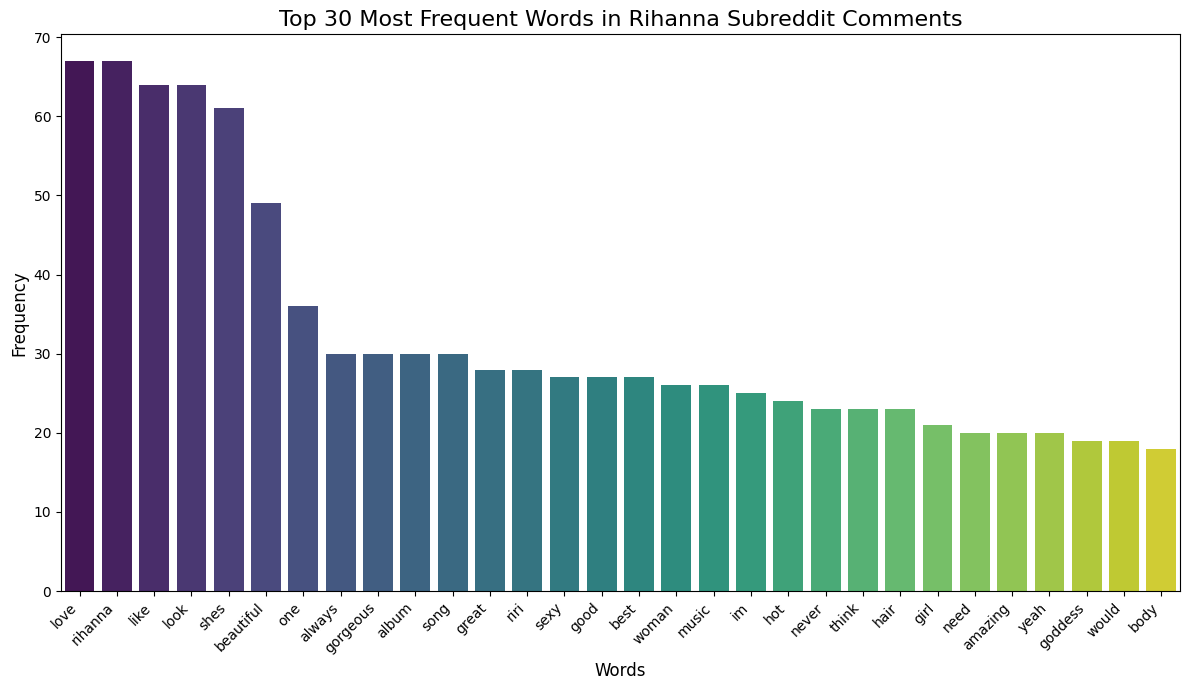

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=[word[0] for word in top_words_data], y=[word[1] for word in top_words_data], palette='viridis')
plt.title('Top {} Most Frequent Words in Rihanna Subreddit Comments'.format(top_n_words), fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Distribution of Comment Scores

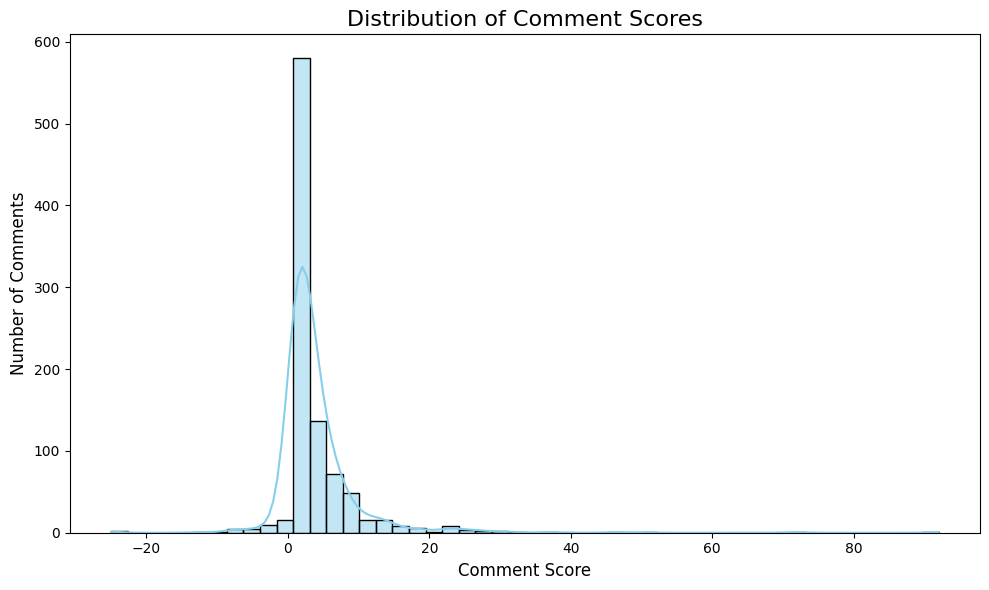

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(rihanna_df_cleaned['score'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Comment Scores', fontsize=16)
plt.xlabel('Comment Score', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.tight_layout()
plt.show()

###Most Engaged Comments

In [ ]:
top_engaged_comments = rihanna_df_cleaned.sort_values(by='score', ascending=False).head(10).copy()

In [ ]:
if 'submission_title' not in top_engaged_comments.columns:
    top_engaged_comments['submission_title'] = top_engaged_comments['comment_id'].apply(lambda x: 'Comment ID: {}'.format(x))

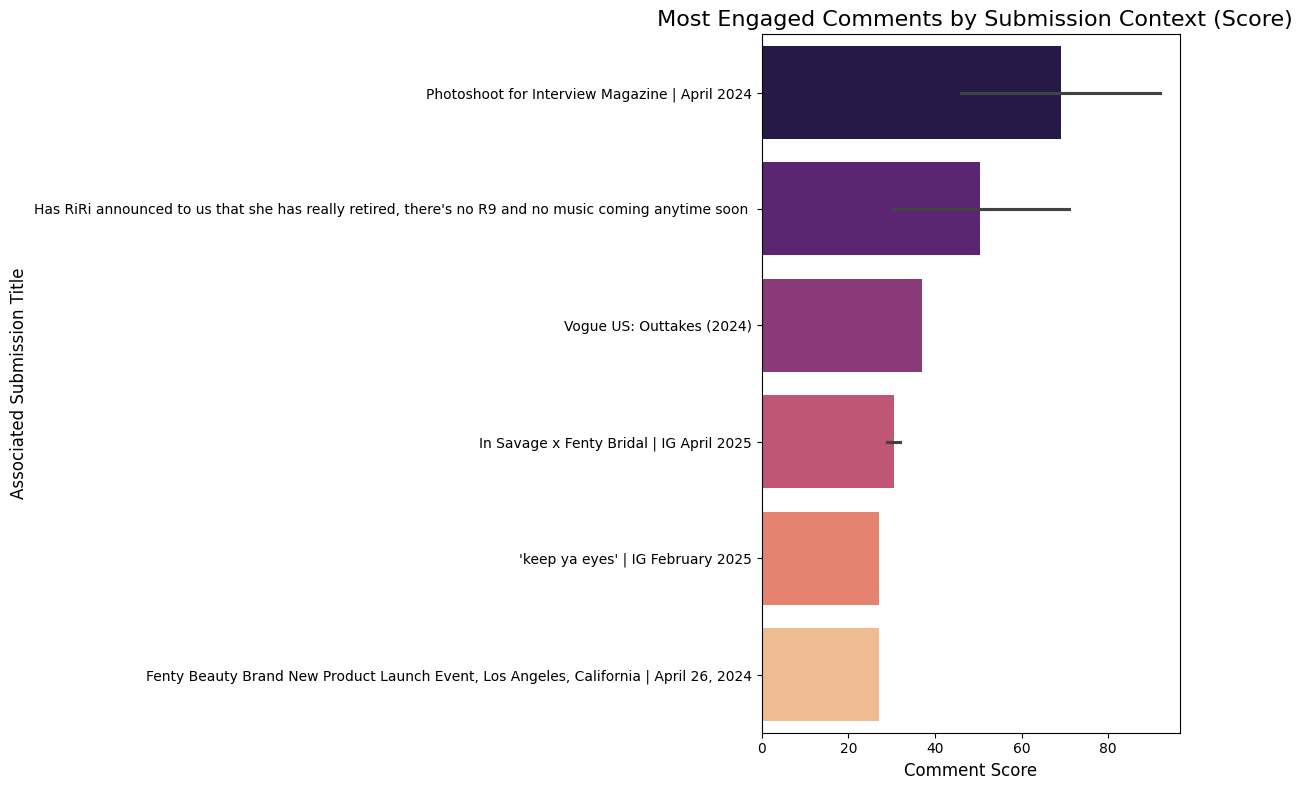

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='score', y='submission_title', data=top_engaged_comments, palette='magma')
plt.title(' Most Engaged Comments by Submission Context (Score)', fontsize=16)
plt.xlabel('Comment Score', fontsize=12)
plt.ylabel('Associated Submission Title', fontsize=12)
plt.tight_layout()
plt.show()

###Comment Activity Over Time

In [ ]:
rihanna_df_cleaned['comment_date'] = rihanna_df_cleaned['created_utc'].dt.date

In [ ]:
daily_comments = rihanna_df_cleaned.groupby('comment_date').size().reset_index(name='comment_count')

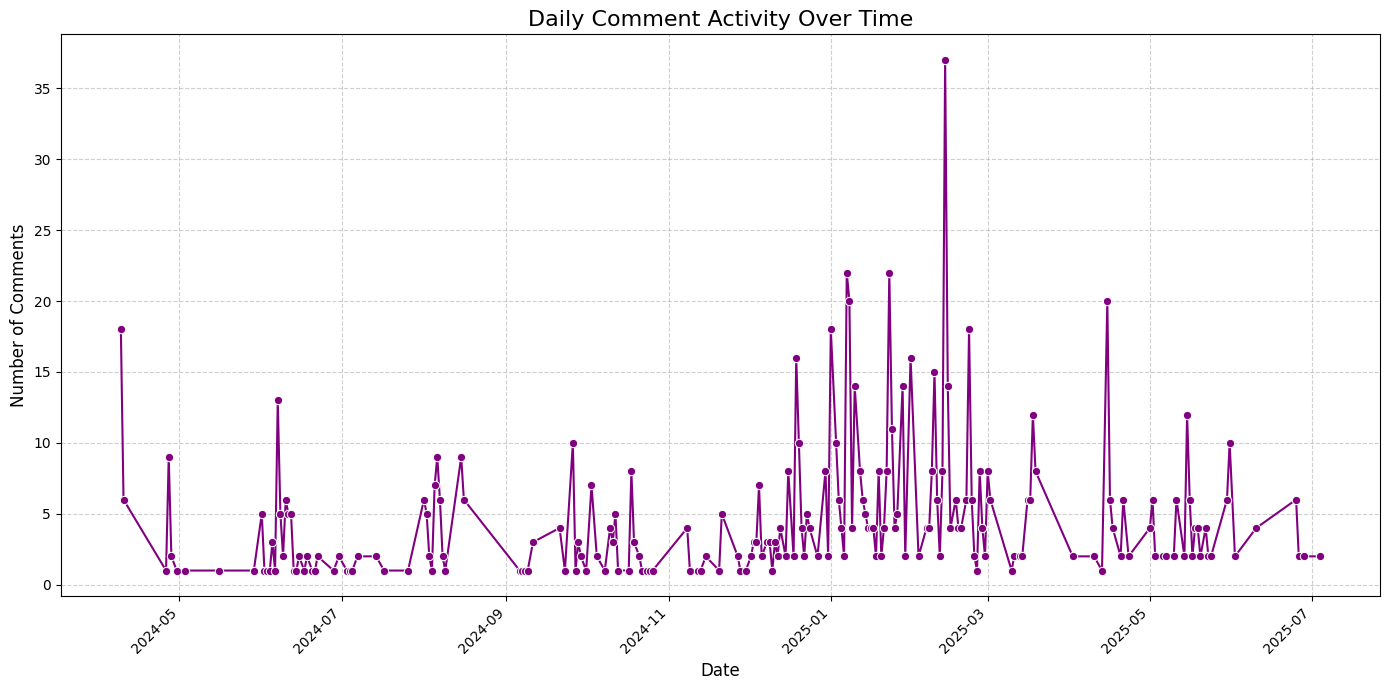

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='comment_date', y='comment_count', data=daily_comments, marker='o', color='purple')
plt.title('Daily Comment Activity Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###Average Comment Score by Day of Week

In [ ]:
rihanna_df_cleaned['day_of_week'] = rihanna_df_cleaned['created_utc'].dt.day_name()

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [ ]:
rihanna_df_cleaned['day_of_week'] = pd.Categorical(rihanna_df_cleaned['day_of_week'], categories=day_order, ordered=True)

In [ ]:
avg_score_by_day = rihanna_df_cleaned.groupby('day_of_week')['score'].mean().reset_index()

/tmp/ipython-input-72-1501915832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_day = rihanna_df_cleaned.groupby('day_of_week')['score'].mean().reset_index()


/tmp/ipython-input-73-1157851048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='score', data=avg_score_by_day, palette='cividis')


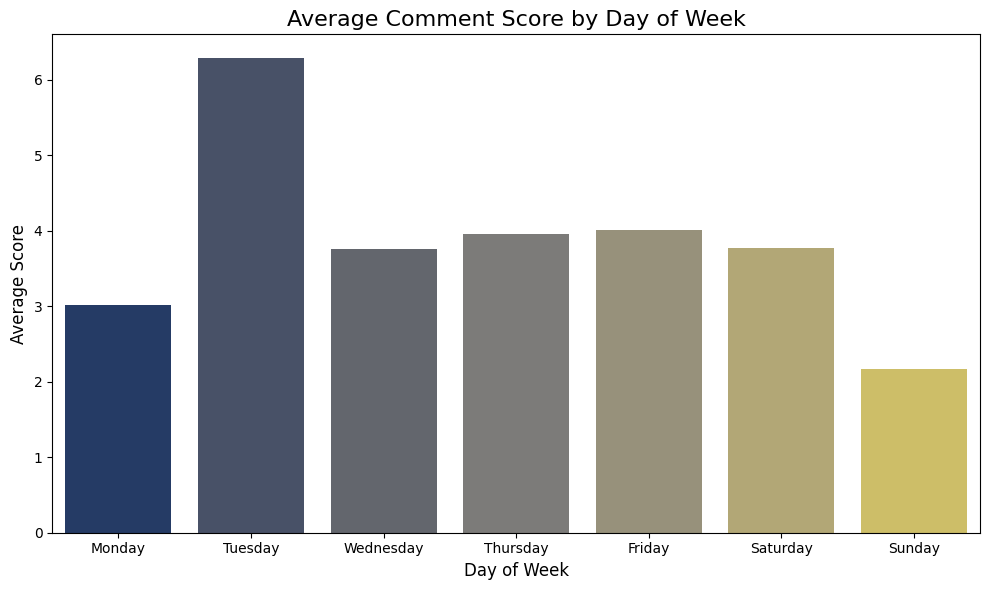

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='score', data=avg_score_by_day, palette='cividis')
plt.title('Average Comment Score by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.tight_layout()
plt.show()

###Sentiment Analysis and Text MIning

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
rihanna_df_cleaned['created_utc'] = pd.to_datetime(rihanna_df_cleaned['created_utc'])

###Sentiment Analysis

In [ ]:
analyzer = SentimentIntensityAnalyzer()
rihanna_df_cleaned['sentiment_scores'] = rihanna_df_cleaned['processed_comment_body'].apply(
    lambda x: analyzer.polarity_scores(str(x)) if pd.notna(x) else {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}
)

In [ ]:
rihanna_df_cleaned['compound_sentiment'] = rihanna_df_cleaned['sentiment_scores'].apply(lambda x: x['compound'])

In [ ]:
rihanna_df_cleaned['compound_sentiment'] = rihanna_df_cleaned['sentiment_scores'].apply(lambda x: x['compound'])

In [ ]:
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
rihanna_df_cleaned['sentiment'] = rihanna_df_cleaned['compound_sentiment'].apply(classify_sentiment)

###Sentiment Distribution

In [ ]:
sentiment_counts = rihanna_df_cleaned['sentiment'].value_counts()
print("Sentiment distribution:\n{}".format(sentiment_counts))

Sentiment distribution:
sentiment
Positive    480
Neutral     359
Negative    103
Name: count, dtype: int64


In [ ]:
colors = {'Positive': 'lightgreen', 'Negative': 'lightcoral', 'Neutral': 'lightskyblue'}
explode = (0.05, 0, 0) # Explode the positive slice for emphasis

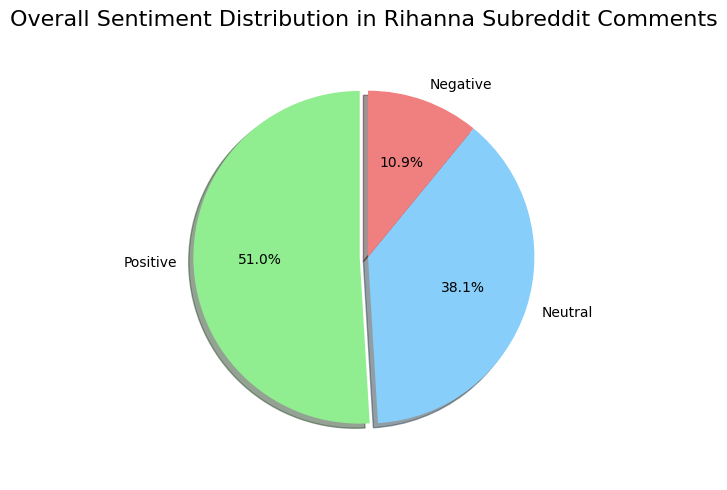

In [ ]:
plt.figure(figsize=(5, 5))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=[colors[s] for s in sentiment_counts.index], startangle=90, explode=explode, shadow=True)
plt.title('Overall Sentiment Distribution in Rihanna Subreddit Comments', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

###Sentiment Over Time

In [ ]:
rihanna_df_cleaned['comment_date'] = rihanna_df_cleaned['created_utc'].dt.date

In [ ]:
daily_sentiment = rihanna_df_cleaned.groupby('comment_date')['compound_sentiment'].mean().reset_index()

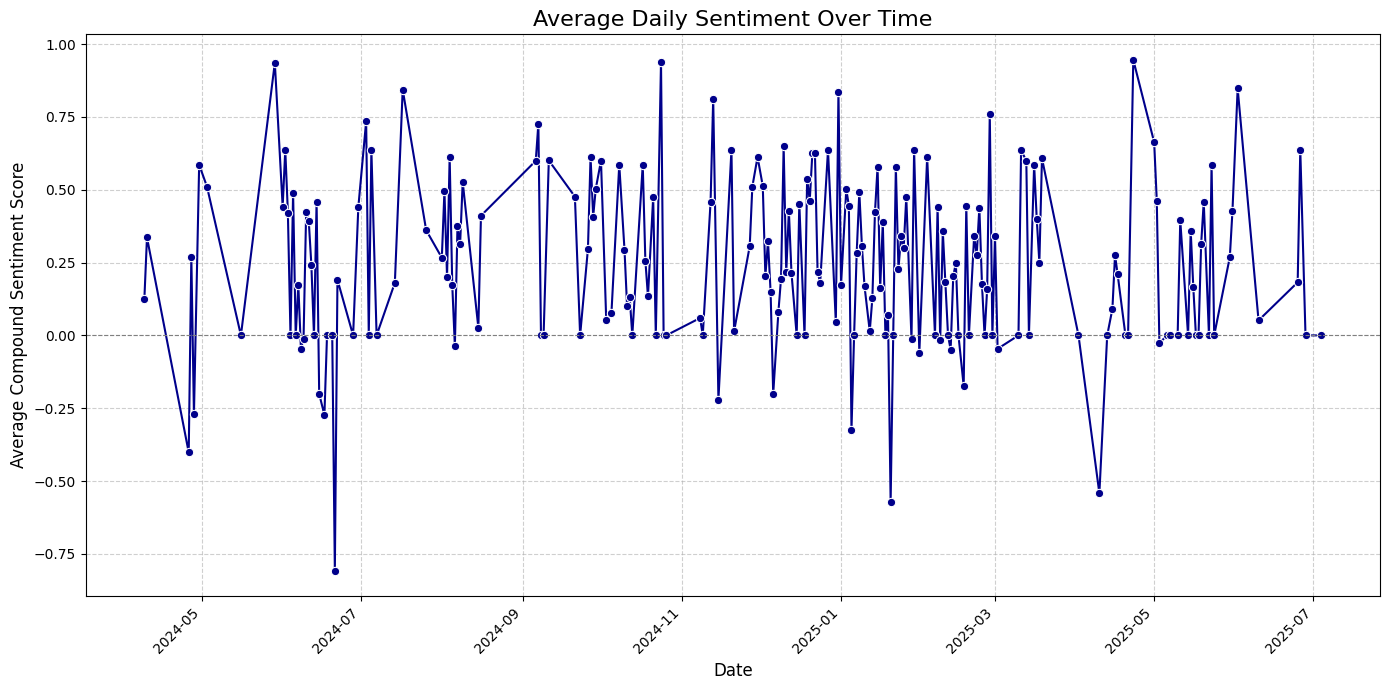

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='comment_date', y='compound_sentiment', data=daily_sentiment, marker='o', color='darkblue')
plt.title('Average Daily Sentiment Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Compound Sentiment Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

###Top Positive and Negative Words

In [ ]:
def get_top_sentiment_words(df, sentiment_type, num_words=15):
    sentiment_comments = df[df['sentiment'] == sentiment_type]['processed_comment_body']

    all_words = ' '.join(sentiment_comments).split()
    word_counts = Counter(all_words)

    exclude_words = ['rihanna', 'fenty', 'music', 'album', 'love', 'new', 'like', 'good', 'great', 'just', 'get', 'dont', 'really', 'would', 'one', 'make']
    filtered_word_counts = {word: count for word, count in word_counts.items() if word not in exclude_words}

    return Counter(filtered_word_counts).most_common(num_words)

In [ ]:
top_positive_words = get_top_sentiment_words(rihanna_df_cleaned, 'Positive')

In [ ]:
top_negative_words = get_top_sentiment_words(rihanna_df_cleaned, 'Negative')

/tmp/ipython-input-91-1815390878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[1] for word in top_positive_words], y=[word[0] for word in top_positive_words], palette='Greens_r')


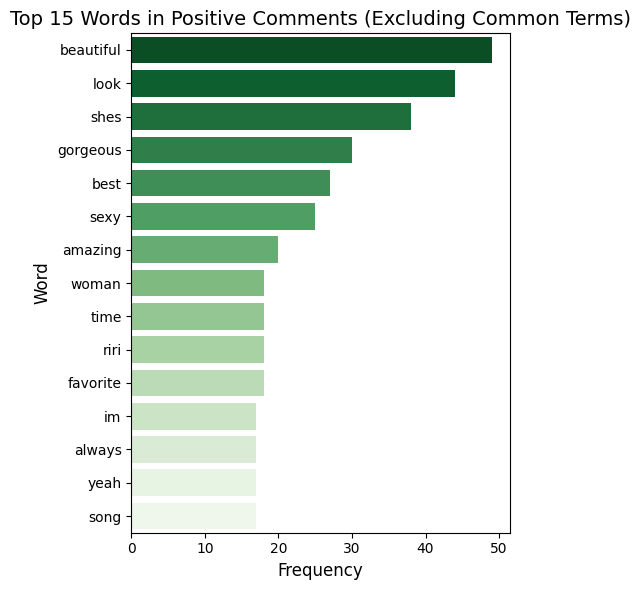

In [ ]:
plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=[word[1] for word in top_positive_words], y=[word[0] for word in top_positive_words], palette='Greens_r')
plt.title('Top 15 Words in Positive Comments (Excluding Common Terms)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()

/tmp/ipython-input-92-1570424193.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[1] for word in top_negative_words], y=[word[0] for word in top_negative_words], palette='Reds_r')


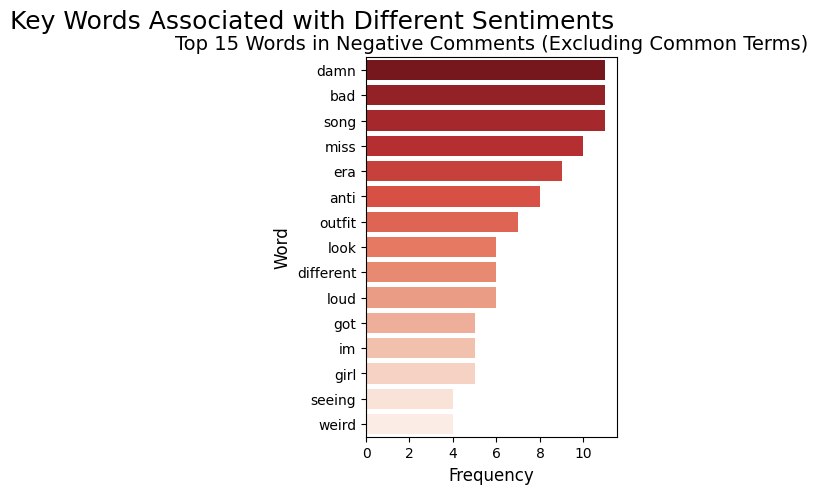

In [ ]:
plt.subplot(1, 2, 2)
sns.barplot(x=[word[1] for word in top_negative_words], y=[word[0] for word in top_negative_words], palette='Reds_r')
plt.title('Top 15 Words in Negative Comments (Excluding Common Terms)', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.suptitle('Key Words Associated with Different Sentiments', fontsize=18, y=1.02)
plt.show()

###Topic Modeling (LDA)

In [ ]:
rihanna_df_cleaned['processed_comment_body'].isna().sum()

np.int64(3)

In [ ]:
vectorizer = CountVectorizer(stop_words='english', min_df=2, max_df=0.9)

In [ ]:
dtm = vectorizer.fit_transform(rihanna_df_cleaned['processed_comment_body'].fillna(''))

In [ ]:
num_topics = 5

In [ ]:
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method='batch', n_jobs=-1)

In [ ]:
lda.fit(dtm)

LatentDirichletAllocation(n_components=5, n_jobs=-1, random_state=42)

In [ ]:
topic_distribution = lda.transform(dtm)

In [ ]:
rihanna_df_cleaned['dominant_topic'] = topic_distribution.argmax(axis=1)

In [ ]:
num_topics

5

In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic {}:".format(topic_idx))
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

In [ ]:
display_topics(lda, feature_names, 10)

Topic 0:
hot shes damn lol rihannas perfect instagram rihanna post say
Topic 1:
look like gorgeous riri best hair rihanna amazing girl talk
Topic 2:
beautiful sexy queen wow love body stunning omg baby aint
Topic 3:
song rihanna pregnant era dont need think album shes anti
Topic 4:
shes love great rihanna woman like goddess yeah im oh


###Topic Distribution Across Comments

In [ ]:
topic_counts = rihanna_df_cleaned['dominant_topic'].value_counts().sort_index()

/tmp/ipython-input-134-3547673225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='coolwarm')


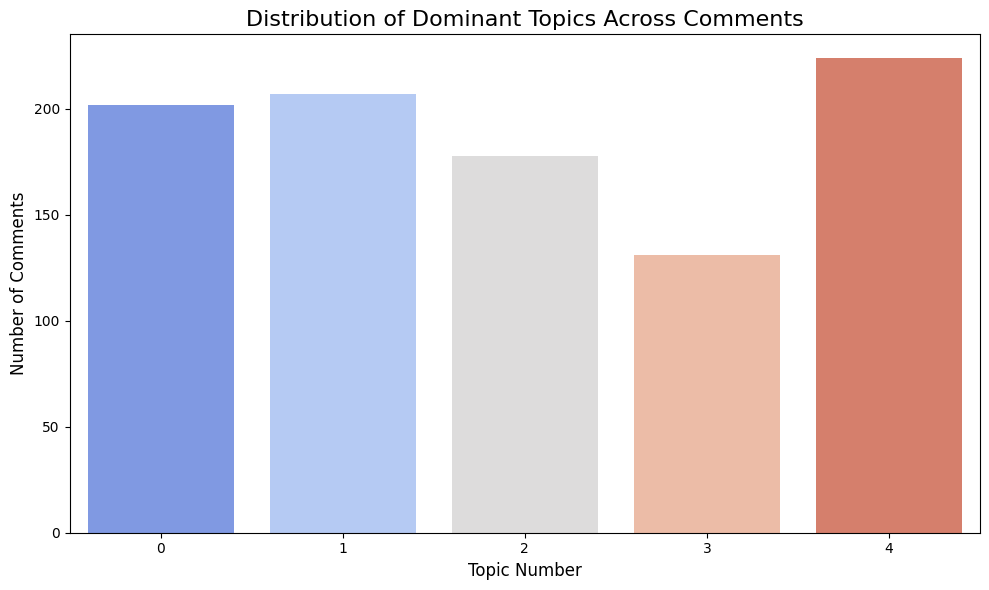

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='coolwarm')
plt.title('Distribution of Dominant Topics Across Comments', fontsize=16)
plt.xlabel('Topic Number', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###Top Words Per Topic

In [ ]:
no_top_words_viz = 10

/tmp/ipython-input-149-4187105783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_strengths, y=top_words, palette='GnBu_d', ax=ax)
/tmp/ipython-input-149-4187105783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_strengths, y=top_words, palette='GnBu_d', ax=ax)
/tmp/ipython-input-149-4187105783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_strengths, y=top_words, palette='GnBu_d', ax=ax)
/tmp/ipython-input-149-4187105783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

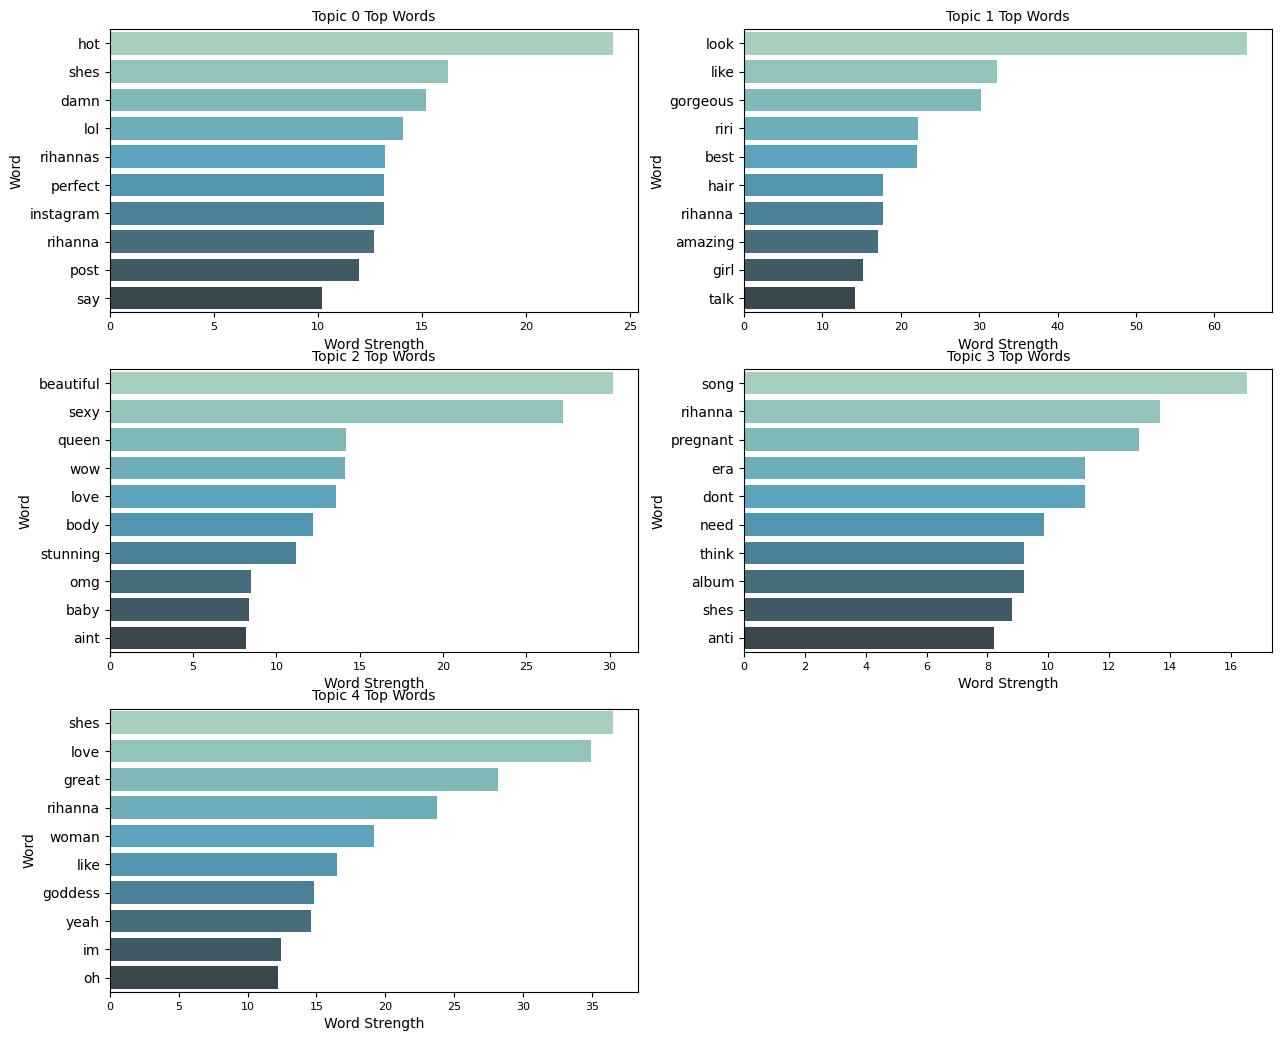

In [ ]:
fig, axes = plt.subplots(int(num_topics/2) + (num_topics%2), 2, figsize=(15, num_topics * 2.5))
axes = axes.flatten()

feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_indices = topic.argsort()[:-no_top_words_viz - 1:-1]
    top_words = [feature_names[i] for i in top_words_indices]
    word_strengths = [topic[i] for i in top_words_indices]



    ax = axes[topic_idx]
    sns.barplot(x=word_strengths, y=top_words, palette='GnBu_d', ax=ax)
    ax.set_title('Topic {} Top Words'.format(topic_idx), fontsize=10)
    ax.set_xlabel('Word Strength', fontsize=10)
    ax.set_ylabel('Word', fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=10)

for i in range(topic_idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.show()